# Physics-Informed Neural Networks (PINNs)

In this notebook, we will solve the diffusion PDE using a Physics-Informed Neural Network (PINN) with the BFGS optimization algorithm. The PDE is given by:
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}.
$$
Here, $\alpha$ is the diffusion coefficient and $u(x,t)$ is the solution we want to find. The initial condition is a Gaussian distribution centered at $x=L/2$ with variance $\sigma^2=200$. The boundary conditions at $x=0$ and $x=L$ are set to be the value of the initial condition at those points for all time:
$$
u(0,t) = u(L,t) = \exp\left(-\frac{(L/2)^2}{200}\right).
$$

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/zhimingkuang/Harvard-AM-115/blob/main/11_diffusion/solve_diffusion_with_pinn_bfgs.ipynb
)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [2]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

## Parameters

In [3]:
# Set random seed for reproducibility
seed = 115
np.random.seed(seed)  # NumPy
torch.manual_seed(seed)  # PyTorch

# For deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


alpha = 1.0  # diffusion coefficient
L = 50.0  # spatial domain [0, L]
T = 100.0  # time domain [0, T]

# Training sample sizes
Nf = 10000  # collocation points
Nb = 20  # boundary points
Ni = 21  # initial condition points

Collocation points are the points in the domain where we will evaluate the loss function of the PiNN. There are many ways to choose these points (uniform sampling, random sampling, sampling in areas of high gradient, etc.). Here, we use a uniform grid of collocation points in the spatial and temporal domains.

The boundary points are the points in the domain where we evaluate the boundary condition loss. Similarly, the initial points are the points where we evaluate the initial condition loss. 

## Training Points

In [4]:
# Collocation points in interior (0<x<L, 0<t<T)
xf = L * torch.rand(Nf, 1)
tf = T * torch.rand(Nf, 1)

# Initial condition points: t=0, x in [0,L]
xi = L * torch.rand(Ni, 1)
ti = torch.zeros_like(xi)
ui = torch.exp(
    -(((xi - L / 2) / 20) ** 2)
)  # Gaussian initial condition centered at L/2=25.0 with variance of 200

# Boundary points: x=0 and x=L, t in [0,T]
tb = T * torch.rand(Nb, 1)  # random points uniformly distributed in time [0, T]
xb0 = torch.zeros(
    Nb, 1
)  # location of the boundary conditions for the time points, here just 0 and L
xbL = L * torch.ones(Nb, 1)

# Here we set boundary condition to stay the same as the initial values.
ub0 = torch.exp(-(((xb0 - L / 2) / 20) ** 2))
ubL = torch.exp(-(((xbL - L / 2) / 20) ** 2))

# Target IC and BC
X0 = torch.cat([xi, xb0, xbL], dim=0)
T0 = torch.cat([ti, tb, tb], dim=0)
U0 = torch.cat([ui, ub0, ubL], dim=0)

# Scale inputs
xf_scaled = xf / L
tf_scaled = tf / T
X0_scaled = X0 / L
T0_scaled = T0 / T

## MLP Definition

The PiNN will be a feedforward neural network with 8 hidden layers and 20 neurons per layer, using the Tanh activation function. The input to the network will be the spatial and temporal coordinates $(x,t)$, and the output will be the predicted solution $u(x,t)$. That is why the input dimension is 2 (for $x$ and $t$) and the output dimension is 1 (for $u$).

In [5]:
# -------------------------
# PINN network
# -------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        input_dim = 2
        hidden_dim = 20
        num_hidden_layers = 8

        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())

        # 8 hidden layers
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        # Output layer
        layers.append(nn.Linear(hidden_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


net = PINN()

## Loss Function

### Nondimensionalization

Typically, for a neural network we scale the input data to be between 0 and 1 to improve training stability. Since our spatial domain is $[0, L]$ and temporal domain is $[0, T]$, we can nondimensionalize the PDE, such that the domain is transformed to $[0, 1] \times [0, 1]$. After nondimensionalization, the PDE becomes:
$$
\frac{\partial u}{\partial \tilde{t}} = \alpha \frac{T}{L^2} \frac{\partial^2 u}{\partial \tilde{x}^2}. \tag{1}
$$

The residual of the PDE is the value we get when we plug the predicted solution from the PiNN into the PDE. Let $\hat{u}(x,t)$ be the output of the PiNN, then the residual is:
$$
r = \frac{\partial \hat{u}}{\partial t} - \alpha \frac{\partial^2 \hat{u}}{\partial x^2}.
$$
If the solution is perfect, then $r = 0$.

<details>
  <summary>Click to for Nondimensionalization Derivation</summary>
  
We define the nondimensional variables as:
$$
\tilde{x} = \frac{x}{L}, \quad \tilde{t} = \frac{t}{T}.
$$

The residual of the PDE is:
$$
r = \frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2}.
$$
When you scale the inputs, the derivatives also get scaled. By the chain rule, we have:
$$
\frac{\partial u}{\partial t} = \frac{\partial u}{\partial \tilde{t}} \cdot \frac{\partial \tilde{t}}{\partial t} = \frac{1}{T} \frac{\partial u}{\partial \tilde{t}},
$$
$$
\frac{\partial^2 u}{\partial x^2} = 
\frac{\partial^2 u}{\partial \tilde{x}^2} \cdot \left(\frac{\partial \tilde{x}}{\partial x}\right)^2 = \frac{1}{L^2} \frac{\partial^2 u}{\partial \tilde{x}^2}.
$$

Substituting these into the PDE gives:
$$
\frac{1}{T} \frac{\partial u}{\partial \tilde{t}} = \alpha \frac{1}{L^2} \frac{\partial^2 u}{\partial \tilde{x}^2} \implies \frac{\partial u}{\partial \tilde{t}} = \alpha \frac{T}{L^2} \frac{\partial^2 u}{\partial \tilde{x}^2}.
$$
  
</details>

### Components of the Loss Function

The loss function for training the PiNN consists of three losses:
1. **PDE Loss**: This is the mean squared error of the PDE residual at the collocation points. It ensures that the predicted solution satisfies the PDE.
2. **Initial Condition Loss**: This is the mean squared error between the predicted solution and the initial condition at the initial points. It ensures that the predicted solution satisfies the initial condition.
3. **Boundary Condition Loss**: This is the mean squared error between the predicted solution and the boundary condition at the boundary points. The total loss is the sum of these three losses.

In [6]:
# -------------------------
# PDE residual
# -------------------------
def pde_residual(net, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    XT = torch.cat([x, t], dim=1)
    u = net(XT)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[
        0
    ]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[
        0
    ]
    u_xx = torch.autograd.grad(
        u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0]
    return u_t - (alpha * T / L**2) * u_xx  # nondimensionalized PDE, equation (1)


# -------------------------
# Loss function
# -------------------------
def loss_function():
    # PDE loss
    r = pde_residual(net, xf_scaled, tf_scaled)
    loss_f = torch.mean(r**2)
    # IC + BC loss
    XT0 = torch.cat([X0_scaled, T0_scaled], dim=1)
    u_pred = net(XT0)
    loss_u = torch.mean((u_pred - U0) ** 2)
    return loss_f + loss_u

## Optimizer

We use the BFGS optimization algorithm to train the PiNN. BFGS is a quasi-Newton method that approximates the Hessian matrix of the loss function to find the optimal parameters. It is often more efficient than gradient descent when the loss landscape is reasonably smooth because the Hessian provides information on the curvature of the loss function. In contrast, gradient descent only uses the first-order gradient information. However, for very large networks or highly nonconvex landscapes, BFGS can become expensive or less effective because the Hessian becomes expensive to compute.

To match the MATLAB implementation of L-BFGS, we set `max_iter=1` and disable the line search by setting `line_search_fn=None`. This ensures that each call to `optimizer.step()` performs exactly one logical L-BFGS update, giving us precise control over the number of optimizer steps in the outer loop. By iterating this way, we can mimic MATLAB’s step-by-step loss recording.

In [7]:
# -------------------------
# L-BFGS optimizer
# -------------------------
optimizer = torch.optim.LBFGS(
    net.parameters(), lr=0.5, max_iter=1, history_size=50, line_search_fn=None
)

# -------------------------
# Outer loop: 300 iterations
# -------------------------
loss_history = []
n_steps = 300

for step in range(n_steps):

    def closure():
        optimizer.zero_grad()
        loss = loss_function()
        loss.backward()
        return loss

    optimizer.step(closure)  # one logical L-BFGS step
    loss_history.append(loss_function().item())  # record one loss per step

## Visualizations

### Loss Curve

The loss curve shows that the loss decreases over the iterations, plateauing around iteration 200.

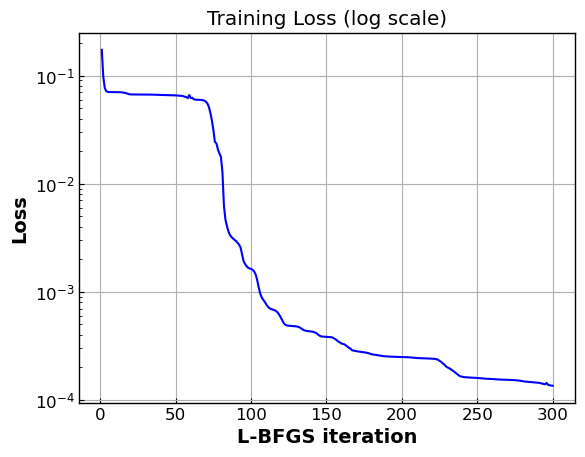

In [8]:
# -------------------------
# Plot loss
# -------------------------
plt.figure()
plt.semilogy(range(1, n_steps + 1), loss_history, "b-", linewidth=1.5)
plt.xlabel("L-BFGS iteration")
plt.ylabel("Loss")
plt.title("Training Loss (log scale)")
plt.grid(True)
plt.show()

### Compare PiNN Solution with Numerical Solution

First we generate points in the spatial and temporal domains to evaluate the PiNN. In the cell below, `xg` is a column vector of spatial points and `tg` is a column vector of time points. We then create a grid of points by combining `xg` and `tg`, and evaluate the PiNN at these points to get the predicted solution `u_pred`. The dimension of `u_pred` is (nx, nt) = (201, 201), where the rows correspond to spatial points and the columns correspond to time points. 

In [9]:
# -------------------------
# Define spatial and temporal evaluation points
# -------------------------
nx, nt = 51, 100  # number of points in x and t
xg = torch.linspace(0, L, nx).reshape(-1, 1)  # spatial points
tg = torch.linspace(0, T, nt).reshape(-1, 1)  # time points

# Scale for the network input
xg_scaled = xg / L
tg_scaled = tg / T

Evaluate the PiNN on the grid of points to get the predicted solution. Note that the predictions are scalar values.

In [10]:
# -------------------------
# Evaluate PINN on the grid
# -------------------------
u_pred = torch.zeros(nx, nt)
for i, t_val in enumerate(tg_scaled):
    XT = torch.cat([xg_scaled, t_val.repeat(nx, 1)], dim=1)
    u_pred[:, i] = net(XT).detach().squeeze()

# The dimesion is (nx, nt) = (201, 201)
# The rows correspond to spatial points and the columns correspond to time points.
u_pred = u_pred.numpy()

#### Time Cross Sections

We plot the PiNN solution and the numerical solution at different time points to visually compare them. The plots show that the PiNN solution closely matches the numerical solution, although not exact. 

The numerical solution uses Method of Lines. We first discretize the spatial domain into a grid and approximate the spatial derivatives using finite differences. This results in a system of ordinary differential equations (ODEs) in time, which we then solve using an ODE solver.

In [11]:
m = 49
dx = 1.0
x = np.linspace(dx, m * dx, m)  # x = 1 to 49

time_e = 100
nt = 100
t_eval = np.linspace(0, time_e, nt)

# -------------------------
# Initial condition
# -------------------------
y0 = np.exp(-(((x - 25) / 20) ** 2))

# Diffusivity
D = 1.0

# -------------------------
# Build Laplacian matrix A
# -------------------------
e1 = np.ones(m)

A = np.diag(-2 * e1)
A += np.diag(e1[:-1], -1)
A += np.diag(e1[:-1], 1)

# -------------------------
# Boundary vector
# -------------------------
b = np.zeros(m)
b[0] = y0[0]  # left boundary value (at x=0)
b[-1] = y0[-1]  # right boundary value (at x=50)


# -------------------------
# Define RHS of ODE system
# -------------------------
def F(t, y):
    return D * (A @ y + b) / dx**2


# -------------------------
# Solve ODE system
# -------------------------
sol = solve_ivp(F, [0, time_e], y0, t_eval=t_eval, method="RK45")

# Solution array
u_fd = sol.y  # shape (m, nt)

# -------------------------
# For plotting, create extended x array including boundaries
# -------------------------
x_extended = np.concatenate([[0], x, [50]])  # [0, 1, 2, ..., 49, 50]

# Extend solution to include boundaries (using Dirichlet BCs)
u_fd_extended = np.zeros((m + 2, nt))
u_fd_extended[0, :] = b[0]  # left boundary (constant from initial condition)
u_fd_extended[1:-1, :] = u_fd  # interior points
u_fd_extended[-1, :] = b[-1]  # right boundary (constant from initial condition)

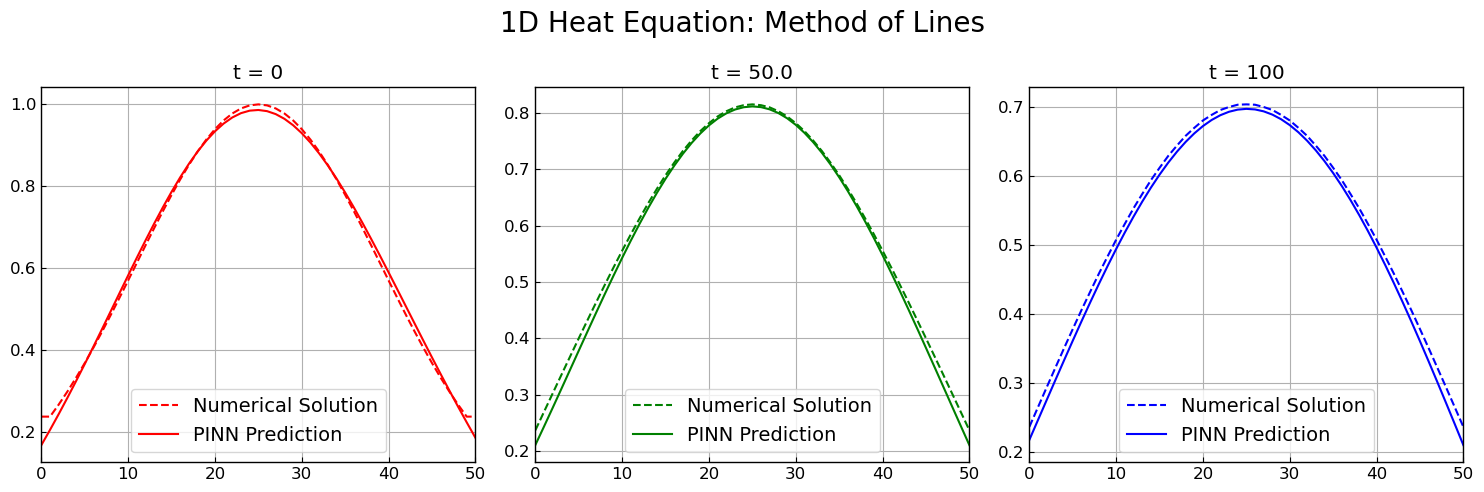

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# t = 0
axes[0].plot(x_extended, u_fd_extended[:, 0], "r--", label="Numerical Solution")
axes[0].plot(xg, u_pred[:, 0], "r-", label="PINN Prediction")
axes[0].set_title("t = 0")
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 50)  # Explicitly set x-axis limits

# t = T/2
axes[1].plot(x_extended, u_fd_extended[:, nt // 2], "g--", label="Numerical Solution")
axes[1].plot(xg.numpy(), u_pred[:, nt // 2], "g-", label="PINN Prediction")
axes[1].set_title(f"t = {time_e/2}")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 50)

# t = T
axes[2].plot(x_extended, u_fd_extended[:, -1], "b--", label="Numerical Solution")
axes[2].plot(xg.numpy(), u_pred[:, -1], "b-", label="PINN Prediction")
axes[2].set_title(f"t = {time_e}")
axes[2].legend()
axes[2].grid(True)
axes[2].set_xlim(0, 50)

plt.suptitle("1D Heat Equation: Method of Lines")
plt.tight_layout()
plt.show()

#### Heatmap

Finally, we plot the heatmap of the PiNN solution and the numerical solution over the entire spatial-temporal domain. The heatmaps show that the PiNN solution captures the overall behavior of the numerical solution, although there may be some discrepancies especially near the boundaries for later time points.

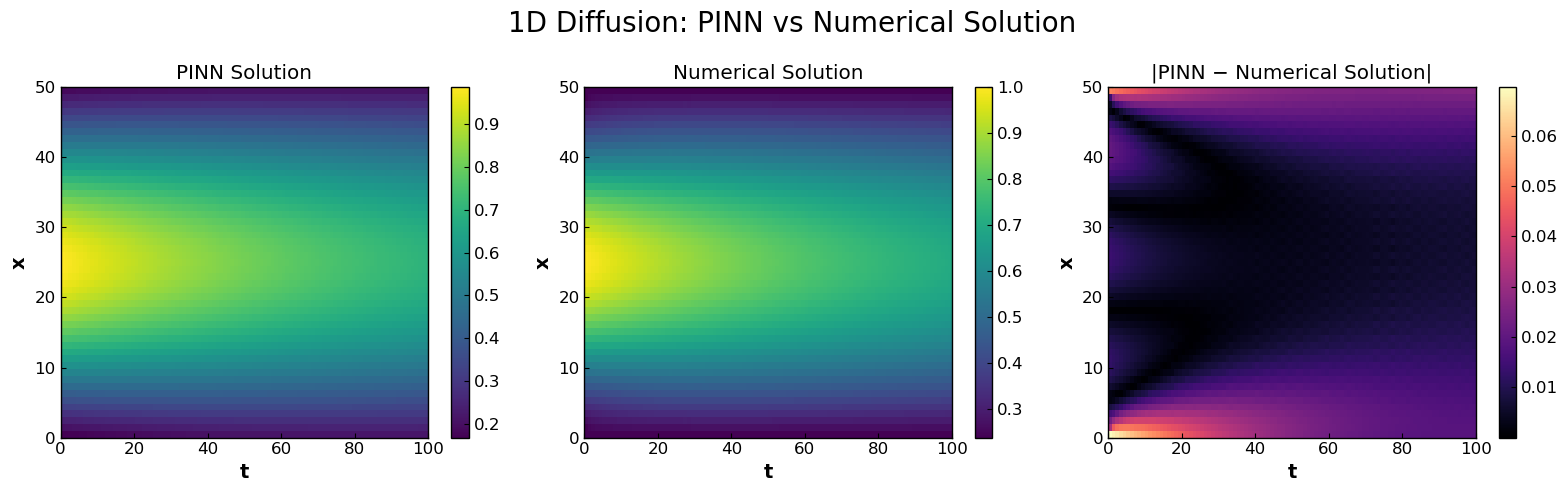

In [13]:
# Compute absolute error
error = np.abs(u_pred - u_fd_extended)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---- PINN solution ----
im0 = axes[0].imshow(
    u_pred,
    extent=[0, T, 0, L],
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
axes[0].set_title("PINN Solution")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x")
plt.colorbar(im0, ax=axes[0])

# ---- Numerical solution ----
im1 = axes[1].imshow(
    u_fd_extended,
    extent=[0, T, 0, L],
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
axes[1].set_title("Numerical Solution")
axes[1].set_xlabel("t")
axes[1].set_ylabel("x")
plt.colorbar(im1, ax=axes[1])

# ---- Error / residual ----
im2 = axes[2].imshow(
    error,
    extent=[0, T, 0, L],
    aspect="auto",
    origin="lower",
    cmap="magma",
)
axes[2].set_title("|PINN − Numerical Solution|")
axes[2].set_xlabel("t")
axes[2].set_ylabel("x")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("1D Diffusion: PINN vs Numerical Solution")
plt.tight_layout()
plt.show()